# Perturbation Methods (Math2015) — Homework 2026

This notebook studies the accuracy of the composite solution of the boundary value problem given in the statement.  
The approximation obtained from perturbation theory is compared with the exact numerical solution.

## Contents

1. Comparison between the exact solution and the leading-order composite solution  
2. Comparison between the exact solution and the \(O(\varepsilon)\) composite solution  
3. Direct comparison between the \(O(1)\), \(O(\varepsilon)\), and exact solutions  
4. Error analysis  

## References and Use of Artificial Intelligence Tools

The implementation and analysis of the first three sections were carried out using the notebooks presented during the theoretical lectures, without the help of any AI tool.

For the last section on error analysis, the mathematical ideas were inspired by material from the course *Modeling with Partial Differential Equations* (Math0024).  
The final cell was implemented with the help of AI tools and then carefully checked and verified.

In [135]:
# Importing usefull libraries
import numpy as np
from scipy.integrate import solve_bvp
import matplotlib.pyplot as plt

In [136]:
def y_exact(x_eval, epsilon):
    
    def fun(x, y):
        return np.vstack((y[1], (2*(x**2 + 1)*y[1] - 1)/epsilon))
    
    def bc(ya, yb):
        return np.array([ya[0], yb[0]])
    
    x_init = np.linspace(0, 1, 100)  # initial mesh with 5 nodes
    y_init = np.zeros((2, x_init.size))
    
    res_a = solve_bvp(fun, bc, x_init, y_init)
    
    return res_a.sol(x_eval)[0]  # exact solution as a function of x_eval

In [137]:
#Impoving Plotting parameters for better visibility

plt.rcParams.update({
    "mathtext.fontset": "cm",
    "figure.autolayout": True,
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "legend.fontsize": 18,
})

# 1) Visualize exact solutions and leading order composite solutions

In [138]:
x_eval = np.linspace(0, 1, 2000)  # interval [0, 1] with 2000 points

epsilon1 = 0.1   # small parameter 0.1
epsilon2 = 0.05  # smaller parameter 0.05
epsilon3 = 0.01  # very small parameter 0.01

In [139]:
y_outer = lambda x: 0.5 * np.arctan(x)  # leading-order outer solution

Y_inner = lambda x, epsilon: (np.pi/8) * (1 - np.exp(-4*(1-x)/epsilon))  # leading-order inner solution

y_composite_0 = lambda x, epsilon: y_outer(x) - (np.pi/8) * np.exp(-4*(1-x)/epsilon)  # composite solution

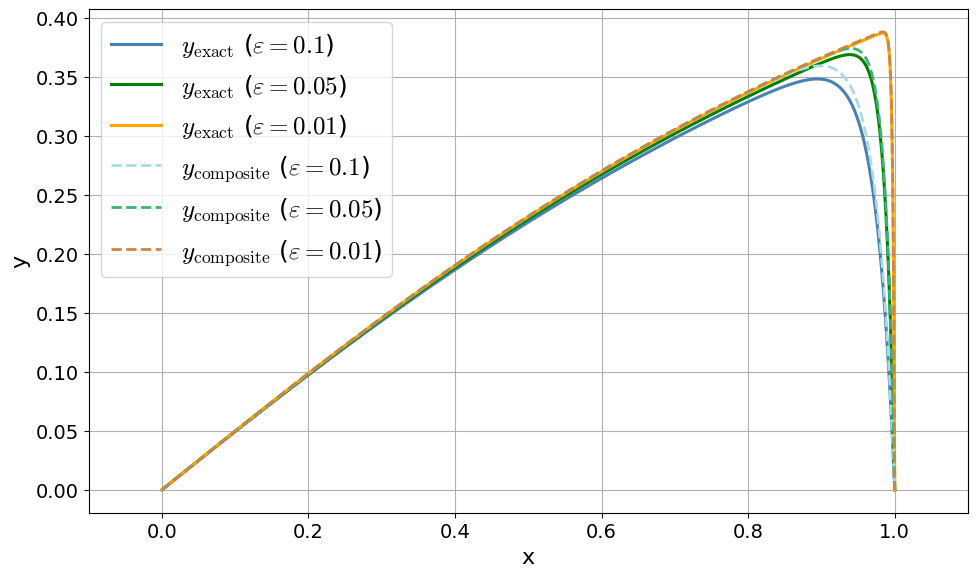

In [140]:
plt.figure(figsize=(10, 6))
plt.plot(x_eval, y_exact(x_eval, epsilon1), label=r'$y_{\mathrm{exact}}$ ($\varepsilon=0.1$)', color='steelblue', linestyle='-', linewidth=2.2)
plt.plot(x_eval, y_exact(x_eval, epsilon2), label=r'$y_{\mathrm{exact}}$ ($\varepsilon=0.05$)', color='green', linestyle='-', linewidth=2.2)
plt.plot(x_eval, y_exact(x_eval, epsilon3), label=r'$y_{\mathrm{exact}}$ ($\varepsilon=0.01$)', color='orange', linestyle='-', linewidth=2.2)
plt.plot(x_eval, y_composite_0(x_eval, epsilon=epsilon1), label=r'$y_{\mathrm{composite}}$ ($\varepsilon=0.1$)', color='lightblue', linestyle='--', linewidth=2.0)
plt.plot(x_eval, y_composite_0(x_eval, epsilon=epsilon2), label=r'$y_{\mathrm{composite}}$ ($\varepsilon=0.05$)', color='mediumseagreen', linestyle='--', linewidth=2.0)
plt.plot(x_eval, y_composite_0(x_eval, epsilon=epsilon3), label=r'$y_{\mathrm{composite}}$ ($\varepsilon=0.01$)', color='peru', linestyle='--', linewidth=2.0)
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-0.1, 1.1)
plt.legend()
plt.grid()
plt.savefig("images/leading-order.pdf", bbox_inches="tight")
plt.show()

# 2) Visualize O($\varepsilon$) corrected composite solution

In [141]:
y_composite_1 = lambda x, epsilon: (
    0.5 * np.arctan(x)
    - (np.pi/8) * np.exp(-4*(1-x)/epsilon)
    + (epsilon/8) * (1/(1 + x**2)**2 - 1)
    + epsilon * np.exp(-4*(1-x)/epsilon) * (
        3/32
        - (np.pi/8) * (1-x)/epsilon
        - (np.pi/4) * ((1-x)/epsilon)**2
    )
)

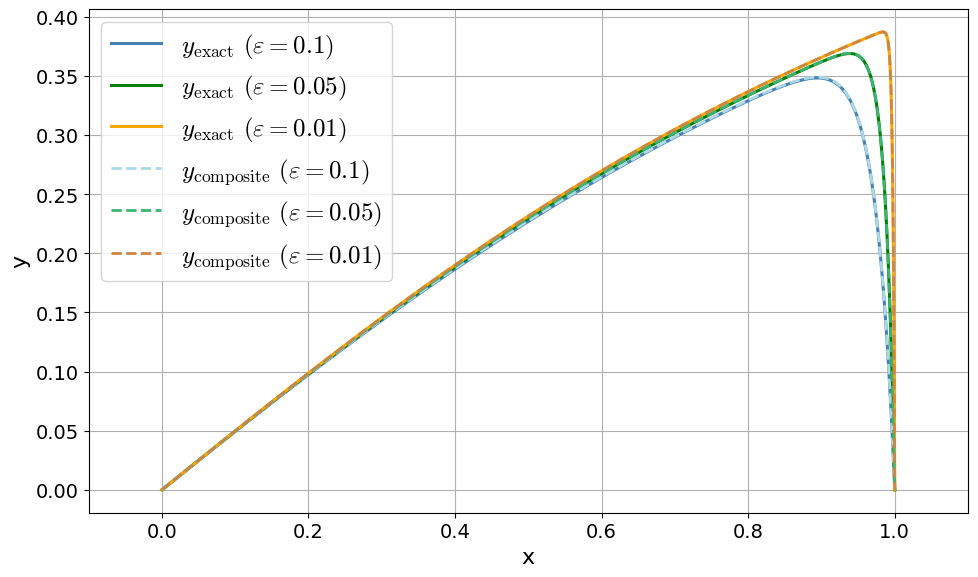

In [142]:
plt.figure(figsize=(10, 6))
plt.plot(x_eval, y_exact(x_eval, epsilon1), label=r'$y_{\mathrm{exact}}$ $(\varepsilon=0.1)$', color='steelblue', linestyle='-', linewidth=2.2)
plt.plot(x_eval, y_exact(x_eval, epsilon2), label=r'$y_{\mathrm{exact}}$ $(\varepsilon=0.05)$', color='green', linestyle='-', linewidth=2.2)
plt.plot(x_eval, y_exact(x_eval, epsilon3), label=r'$y_{\mathrm{exact}}$ $(\varepsilon=0.01)$', color='orange', linestyle='-', linewidth=2.2)
plt.plot(x_eval, y_composite_1(x_eval, epsilon=epsilon1), label=r'$y_{\mathrm{composite}}$ $(\varepsilon=0.1)$', color='lightblue', linestyle='--', linewidth=2.0)
plt.plot(x_eval, y_composite_1(x_eval, epsilon=epsilon2), label=r'$y_{\mathrm{composite}}$ $(\varepsilon=0.05)$', color='mediumseagreen', linestyle='--', linewidth=2.0)
plt.plot(x_eval, y_composite_1(x_eval, epsilon=epsilon3), label=r'$y_{\mathrm{composite}}$ $(\varepsilon=0.01)$', color='peru', linestyle='--', linewidth=2.0)
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-0.1, 1.1)
plt.legend()
plt.grid()
plt.savefig("images/epsilon-order.pdf", bbox_inches="tight")
plt.show()

# 3) Comparison of the solutions at different orders for $\varepsilon$ = 0.1

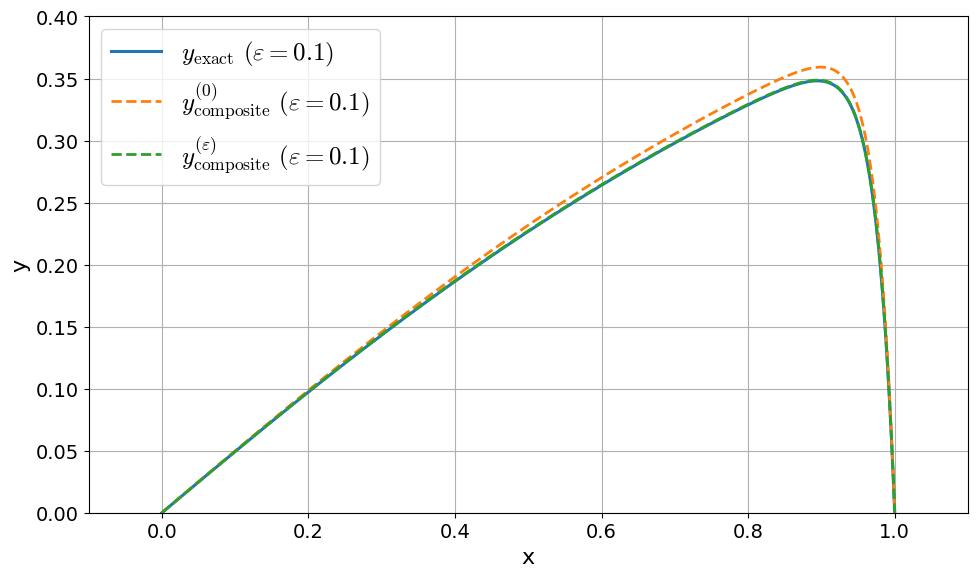

In [143]:
plt.figure(figsize=(10, 6))
plt.plot(x_eval, y_exact(x_eval, epsilon1), label=r'$y_{\mathrm{exact}}$ $(\varepsilon=0.1)$', linestyle='-', linewidth=2.2)
plt.plot(x_eval, y_composite_0(x_eval, epsilon=epsilon1), label=r'$y_{\mathrm{composite}}^{(0)}$ $(\varepsilon=0.1)$', linestyle='--', linewidth=2.0)
plt.plot(x_eval, y_composite_1(x_eval, epsilon=epsilon1), label=r'$y_{\mathrm{composite}}^{(\varepsilon)}$ $(\varepsilon=0.1)$', linestyle='--', linewidth=2.0)
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-0.1, 1.1)
plt.ylim(0, 0.40)
plt.legend()
plt.grid()
plt.savefig("images/various-order.pdf", bbox_inches="tight")
plt.show()

# 4) Analysis of the error

In [144]:
from scipy.integrate import trapezoid

 epsilon |        model |        L_inf |           L2 |    rel L_inf |       rel L2
     0.1 |         O(1) |   1.3523e-02 |   6.3105e-03 |   3.8844e-02 |   2.7458e-02
     0.1 |   O(epsilon) |   5.7191e-04 |   4.2800e-04 |   1.6427e-03 |   1.8623e-03
------------------------------------------------------------------------------------------
    0.05 |         O(1) |   6.7521e-03 |   2.9508e-03 |   1.8310e-02 |   1.2351e-02
    0.05 |   O(epsilon) |   1.5345e-04 |   1.1566e-04 |   4.1612e-04 |   4.8413e-04
------------------------------------------------------------------------------------------
    0.01 |         O(1) |   1.3459e-03 |   5.5351e-04 |   3.4773e-03 |   2.2508e-03
    0.01 |   O(epsilon) |   9.6340e-06 |   4.9453e-06 |   2.4891e-05 |   2.0110e-05
------------------------------------------------------------------------------------------


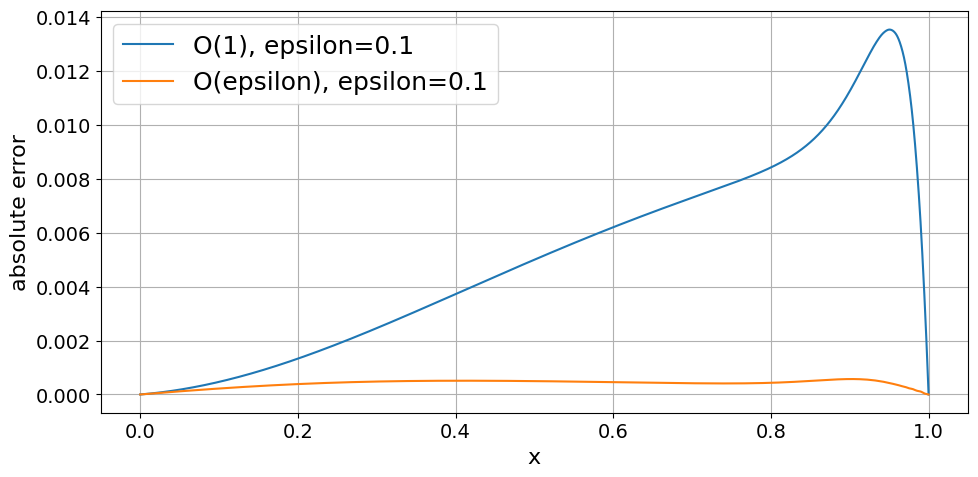

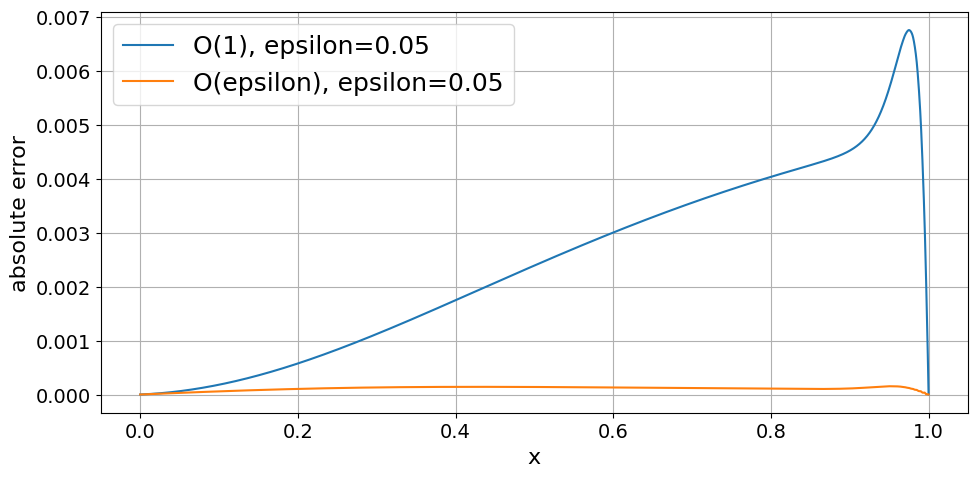

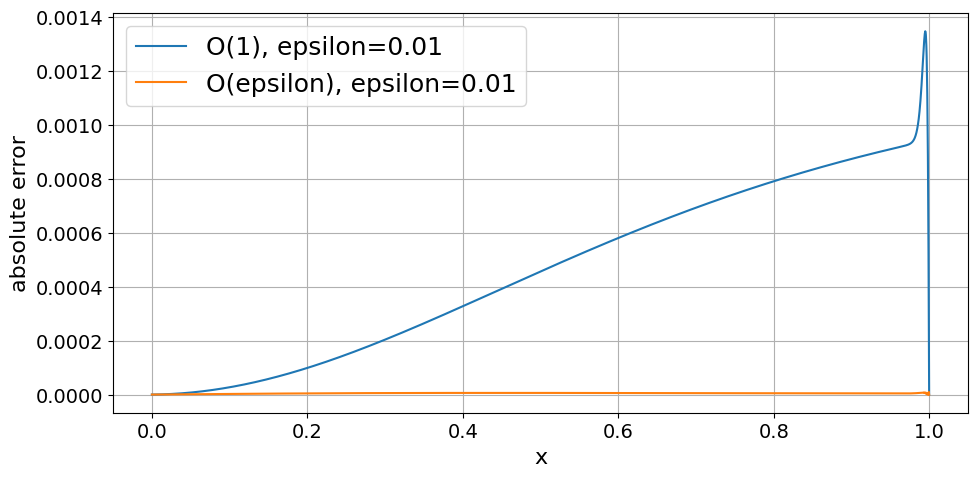


Maximum error location:
epsilon = 0.1, model = O(1): max error = 1.3523e-02 at x = 0.950390
epsilon = 0.1, model = O(epsilon): max error = 5.7191e-04 at x = 0.900780
epsilon = 0.05, model = O(1): max error = 6.7521e-03 at x = 0.975195
epsilon = 0.05, model = O(epsilon): max error = 1.5345e-04 at x = 0.954391
epsilon = 0.01, model = O(1): max error = 1.3459e-03 at x = 0.994999
epsilon = 0.01, model = O(epsilon): max error = 9.6340e-06 at x = 0.999600


In [145]:
x = np.linspace(0.0, 1.0, 5000)
epsilons = [0.1, 0.05, 0.01]

def compute_errors(y_ref, y_approx, x):
    err = y_approx - y_ref
    abs_err = np.abs(err)

    L_inf = np.max(abs_err)
    L2 = np.sqrt(np.trapezoid(err**2, x))

    ref_L_inf = np.max(np.abs(y_ref))
    ref_L2 = np.sqrt(np.trapezoid(y_ref**2, x))

    rel_L_inf = L_inf / ref_L_inf if ref_L_inf != 0 else np.nan
    rel_L2 = L2 / ref_L2 if ref_L2 != 0 else np.nan

    return L_inf, L2, rel_L_inf, rel_L2, abs_err

results = {}

print("=" * 90)
print(f"{'epsilon':>8} | {'model':>12} | {'L_inf':>12} | {'L2':>12} | {'rel L_inf':>12} | {'rel L2':>12}")
print("=" * 90)

for eps in epsilons:
    y_ref = y_exact(x, eps)
    y0 = y_composite_0(x, eps)
    y1 = y_composite_1(x, eps)

    L_inf_0, L2_0, rel_L_inf_0, rel_L2_0, err0 = compute_errors(y_ref, y0, x)
    L_inf_1, L2_1, rel_L_inf_1, rel_L2_1, err1 = compute_errors(y_ref, y1, x)

    results[eps] = {
        "O(1)": err0,
        "O(epsilon)": err1
    }

    print(f"{eps:8.3g} | {'O(1)':>12} | {L_inf_0:12.4e} | {L2_0:12.4e} | {rel_L_inf_0:12.4e} | {rel_L2_0:12.4e}")
    print(f"{eps:8.3g} | {'O(epsilon)':>12} | {L_inf_1:12.4e} | {L2_1:12.4e} | {rel_L_inf_1:12.4e} | {rel_L2_1:12.4e}")
    print("-" * 90)

# Plot pointwise absolute error
for eps in epsilons:
    err0 = results[eps]["O(1)"]
    err1 = results[eps]["O(epsilon)"]

    plt.figure(figsize=(10, 5))
    plt.plot(x, err0, label=f'O(1), epsilon={eps}')
    plt.plot(x, err1, label=f'O(epsilon), epsilon={eps}')
    plt.xlabel("x")
    plt.ylabel("absolute error")
    plt.grid(True)
    plt.legend()
    plt.show()

# Print where the max error is
print("\nMaximum error location:")
print("=" * 60)

for eps in epsilons:
    for name in ["O(1)", "O(epsilon)"]:
        err = results[eps][name]
        i = np.argmax(err)
        print(f"epsilon = {eps}, model = {name}: max error = {err[i]:.4e} at x = {x[i]:.6f}")